In [2]:
import pandas as pd

print(pd.__version__)

3.0.2


In [3]:
activities = pd.read_csv("data/activity_level.csv")
public = pd.read_csv("data/public_signups.csv")
volunteers = pd.read_csv("data/volunteer_signups.csv")

print("Activities:", activities.shape)
print("Public:", public.shape)
print("Volunteers:", volunteers.shape)

Activities: (26682, 34)
Public: (156535, 9)
Volunteers: (49735, 4)


In [4]:
activities.head()
activities.columns.tolist()

['ActivityID',
 'Date',
 'StartTime',
 'EndTime',
 'Duration',
 'ActivityType',
 'ActivitySubType',
 'ActivityName',
 'Organization',
 'Volunteers',
 'VolunteerHours',
 'Staff',
 'StaffHours',
 'VisitorsRegistered',
 'VisitorsNoShow',
 'VisitorsWalkUp',
 'VisitorsChildren',
 'VisitorsRegisteredIrvineResident',
 'VisitorsRegisteredIrvineNonResident',
 'TotalVisitors',
 'TotalGuests',
 'IsIrcLed',
 'IsPrivate',
 'ActivityStatus',
 'IsUnlisted',
 'IsLegacy',
 'CancelReason',
 'WalkUpVolunteers',
 'WalkUpVolunteerHours',
 'activity_title',
 'event_id',
 'event_start_date',
 'public_visitor_slots',
 'cancel_reason_label']

In [5]:
activities["ActivityID"].nunique(), len(activities)

(26678, 26682)

In [6]:
activities[activities.duplicated(subset=["ActivityID"], keep=False)]

,ActivityID,Date,StartTime,EndTime,Duration,ActivityType,ActivitySubType,ActivityName,Organization,Volunteers,...,IsUnlisted,IsLegacy,CancelReason,WalkUpVolunteers,WalkUpVolunteerHours,activity_title,event_id,event_start_date,public_visitor_slots,cancel_reason_label
11224,89118,1/18/2021,16:30:00,17:15:00,0.75,Interpretive,NaN,Visit (Virtually) Nature in your Backyard for ...,City of Irvine,2,...,0,0,0,0,0,Visit (Virtually) Nature in your Backyard for ...,35894,1/18/2021,25.0,NaN
11225,89118,1/18/2021,16:30:00,17:15:00,0.75,Interpretive,NaN,Visit (Virtually) Nature in your Backyard for ...,City of Irvine,2,...,0,0,0,0,0,Visit (Virtually) Nature in your Backyard for ...,35894,1/18/2021,10.0,NaN
19105,51374,7/12/2017,8:00:00,14:00:00,6.00,Fire Watch,NaN,Fire Watch: Volunteer Video Shoot,City of Irvine,1,...,0,0,0,0,0,Fire Watch: Volunteer Video Shoot,19572,7/12/2017,NaN,NaN
19106,51374,7/12/2017,8:00:00,14:00:00,6.00,Fire Watch,NaN,Fire Watch: Volunteer Video Shoot,City of Newport Beach,2,...,0,0,0,0,0,Fire Watch: Volunteer Video Shoot,19572,7/12/2017,NaN,NaN
19107,51374,7/12/2017,8:00:00,14:00:00,6.00,Fire Watch,NaN,Fire Watch: Volunteer Video Shoot,OC Parks,3,...,0,0,0,0,0,Fire Watch: Volunteer Video Shoot,19572,7/12/2017,NaN,NaN
22490,28798,11/1/2015,9:00:00,14:00:00,5.00,Stewardship,Citizen Science,Citizen Science Butterfly Count in Limestone C...,OC Parks,10,...,1,0,0,0,0,Citizen Science Butterfly Count in Limestone C...,8511,11/1/2015,10.0,NaN
22491,28798,11/1/2015,9:00:00,14:00:00,5.00,Stewardship,Citizen Science,Citizen Science Butterfly Count in Limestone C...,OC Parks,10,...,1,0,0,0,0,Citizen Science Butterfly Count in Limestone C...,8511,11/1/2015,10.0,NaN


In [7]:
activities['Date'] = pd.to_datetime(activities['Date'])

activities['Year'] = activities['Date'].dt.year
activities['Month'] = activities['Date'].dt.month_name()
activities['DayOfWeek'] = activities['Date'].dt.day_name()

activities[['Date', 'Year', 'Month', 'DayOfWeek']].head()

,Date,Year,Month,DayOfWeek
0,2026-05-31,2026,May,Sunday
1,2026-05-31,2026,May,Sunday
2,2026-05-31,2026,May,Sunday
3,2026-05-31,2026,May,Sunday
4,2026-05-31,2026,May,Sunday


In [18]:
activities['ActivityStatus'].value_counts()

ActivityStatus
Closed       22962
Cancelled     3701
Reported        19
Name: count, dtype: int64

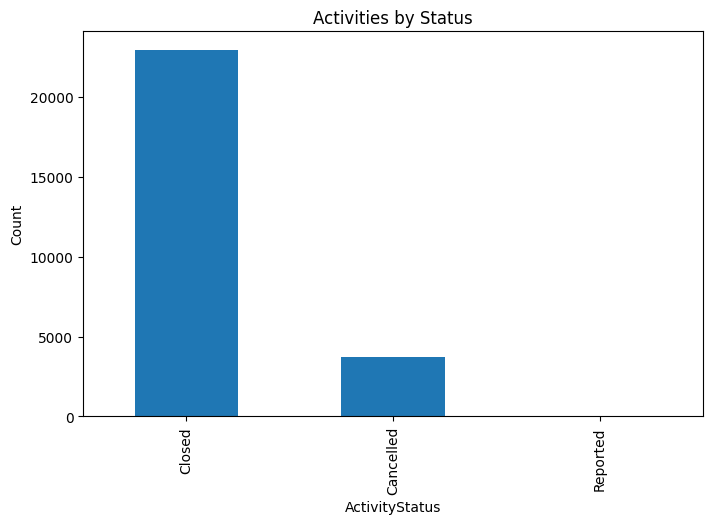

In [21]:
import matplotlib.pyplot as plt
activities['ActivityStatus'].value_counts().plot(
    kind='bar',
    figsize=(8,5),
    title='Activities by Status'
)
plt.ylabel('Count')
plt.show()

In [ ]:
#Creating a cleaner dataframe with only active activities
active_activities = activities[
    activities['ActivityStatus'].isin(['Closed', 'Reported'])
].copy()

print(active_activities.shape)

(22981, 37)


In [23]:
activities_per_year = (
    active_activities.groupby('Year')
    .size()
    .sort_index()
)

activities_per_year

Year
2013     548
2014    1750
2015    1687
2016    1832
2017    2040
2018    2142
2019    1853
2020    1313
2021    1309
2022    1508
2023    1598
2024    2013
2025    2413
2026     975
dtype: int64

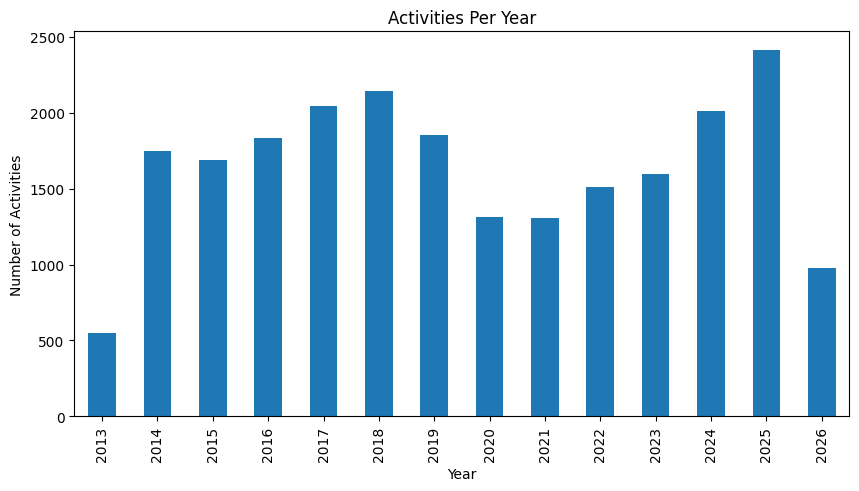

In [24]:
activities_per_year.plot(
    kind='bar',
    figsize=(10,5),
    title='Activities Per Year'
)

plt.ylabel('Number of Activities')
plt.show()

In [25]:
visitors_per_year = (
    active_activities.groupby('Year')['TotalVisitors']
    .sum()
)

visitors_per_year

Year
2013     4312
2014    18115
2015    16213
2016    16401
2017    15147
2018    15945
2019    14505
2020     4597
2021     5381
2022    12585
2023    12968
2024    15628
2025    18540
2026     7452
Name: TotalVisitors, dtype: int64

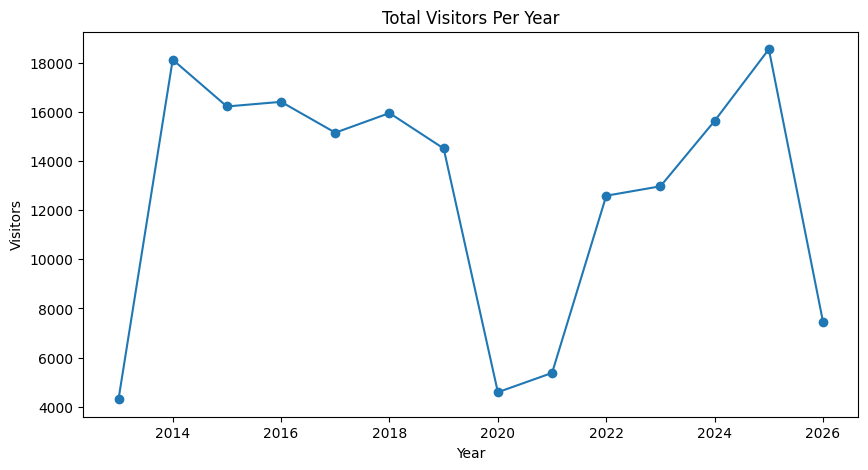

In [26]:
visitors_per_year.plot(
    kind='line',
    marker='o',
    figsize=(10,5),
    title='Total Visitors Per Year'
)

plt.ylabel('Visitors')
plt.show()

In [27]:
volunteer_hours_year = (
    active_activities.groupby('Year')['VolunteerHours']
    .sum()
)

volunteer_hours_year

Year
2013     7469.2500
2014    21723.0000
2015    24717.5000
2016    27385.7500
2017    33274.1170
2018    34727.7500
2019    31835.2500
2020    17119.2500
2021    18709.7500
2022    27481.5000
2023    29078.6667
2024    32922.7500
2025    37399.2500
2026    16805.2500
Name: VolunteerHours, dtype: float64

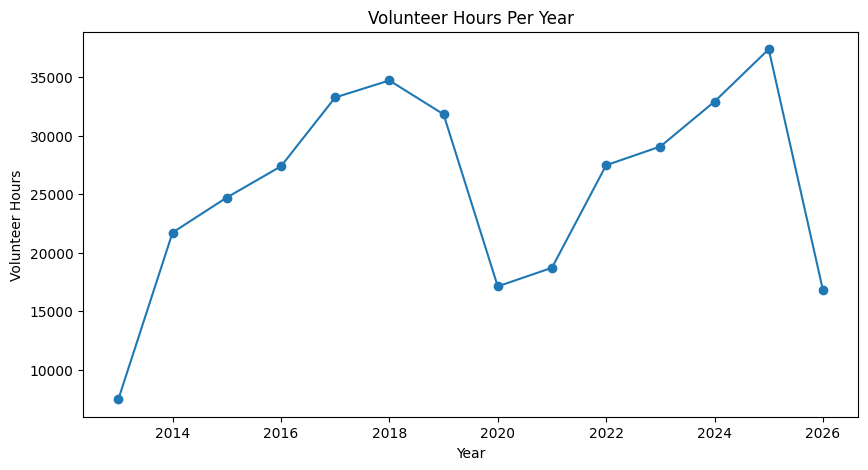

In [28]:
volunteer_hours_year.plot(
    kind='line',
    marker='o',
    figsize=(10,5),
    title='Volunteer Hours Per Year'
)

plt.ylabel('Volunteer Hours')
plt.show()

In [29]:
top_visitors = (
    active_activities.groupby('ActivityType')['TotalVisitors']
    .sum()
    .sort_values(ascending=False)
)

top_visitors

ActivityType
Hiking & Fitness        73198
Special Events          49179
Interpretive            22593
Mountain Biking         13407
Stewardship             13285
Multi-Use Recreation     3372
Equestrian               1463
Engagement                702
Trail Work                373
Training                   58
Community Science          21
Water                       1
Fire Watch                  0
Name: TotalVisitors, dtype: int64

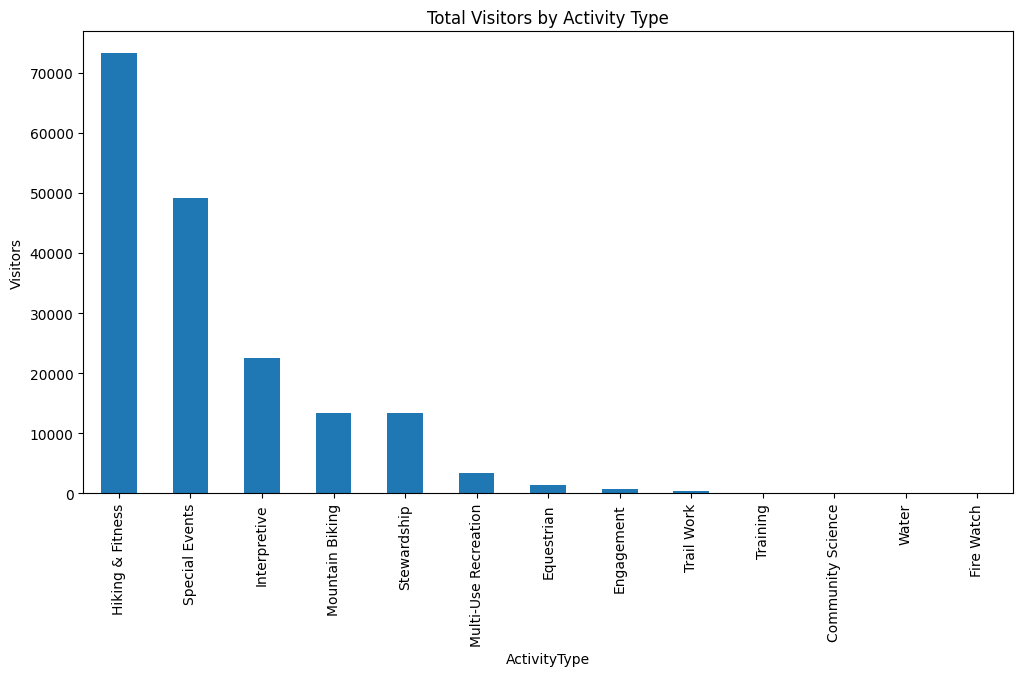

In [30]:
top_visitors.plot(
    kind='bar',
    figsize=(12,6),
    title='Total Visitors by Activity Type'
)

plt.ylabel('Visitors')
plt.show()

In [31]:
activity_efficiency = (
    active_activities.groupby('ActivityType')
    .agg(
        Activities=('ActivityID', 'count'),
        Visitors=('TotalVisitors', 'sum')
    )
)

activity_efficiency['VisitorsPerActivity'] = (
    activity_efficiency['Visitors']
    / activity_efficiency['Activities']
)

activity_efficiency.sort_values(
    'VisitorsPerActivity',
    ascending=False
)

,Activities,Visitors,VisitorsPerActivity
ActivityType,,,
Special Events,476,49179,103.317227
Multi-Use Recreation,51,3372,66.117647
Mountain Biking,994,13407,13.487928
Hiking & Fitness,7313,73198,10.009299
Engagement,72,702,9.750000
Interpretive,2643,22593,8.548241
Community Science,4,21,5.250000
Equestrian,506,1463,2.891304
Stewardship,6321,13285,2.101724


In [8]:
public.shape

(156535, 9)

In [9]:
public["ActivityID"].nunique()

15009

In [10]:
volunteers.shape

(49735, 4)

In [11]:
volunteers["ActivityID"].nunique()

23027

In [12]:
activities["ActivityStatus"].value_counts()

ActivityStatus
Closed       22962
Cancelled     3701
Reported        19
Name: count, dtype: int64

In [13]:
activities["ActivityType"].value_counts()

ActivityType
Hiking & Fitness        8706
Stewardship             7331
Interpretive            3180
Fire Watch              2900
Mountain Biking         1276
Trail Work              1002
Training                 795
Equestrian               724
Special Events           552
Engagement                81
Multi-Use Recreation      56
Water                      7
Community Science          4
Name: count, dtype: int64

In [14]:
activities["ActivitySubType"].value_counts().head(20)

ActivitySubType
Native Farm                    1821
Citizen Science                1749
Restoration                    1575
Invasive Removal                716
CPR/First Aid                   279
Human Access Monitoring         181
Volunteer Position Training     131
Ongoing Education               111
Public Interaction Workshop      57
IRC Orientation                  31
Lead Position Training           21
Community Trail Work              3
OCP Orientation/PIW               2
Fire Watch                        1
Name: count, dtype: int64

In [15]:
activities.groupby("ActivityType")["TotalVisitors"].mean().sort_values(ascending=False)

ActivityType
Special Events          98.898551
Multi-Use Recreation    60.214286
Mountain Biking         11.978840
Hiking & Fitness         9.636572
Interpretive             8.708805
Engagement               8.666667
Community Science        5.250000
Equestrian               2.480663
Stewardship              1.986223
Trail Work               0.392216
Water                    0.142857
Training                 0.080503
Fire Watch               0.000000
Name: TotalVisitors, dtype: float64

In [16]:
activities.groupby("ActivityType")["TotalVisitors"]\
    .sum()\
    .sort_values(ascending=False)

ActivityType
Hiking & Fitness        83896
Special Events          54592
Interpretive            27694
Mountain Biking         15285
Stewardship             14561
Multi-Use Recreation     3372
Equestrian               1796
Engagement                702
Trail Work                393
Training                   64
Community Science          21
Water                       1
Fire Watch                  0
Name: TotalVisitors, dtype: int64

In [17]:
activities.groupby("ActivityType")["VolunteerHours"]\
    .sum()\
    .sort_values(ascending=False)

ActivityType
Hiking & Fitness        141187.2500
Stewardship              80852.0000
Interpretive             50594.2837
Training                 36318.3750
Special Events           34363.5000
Fire Watch               28510.0000
Mountain Biking          21194.5000
Equestrian               10715.5000
Trail Work               10657.0000
Multi-Use Recreation      2205.5000
Engagement                 775.2500
Water                       91.5000
Community Science           61.2500
Name: VolunteerHours, dtype: float64